# Crosscoder Data Loading Inspection
This script shows how tokens are loaded from the HF dataset and processed for crosscoder training

## Setup

In [1]:
import os
import sys
import yaml
import torch
from pathlib import Path

# Patch for the Self type hint issue
# We'll monkey patch the typing module to add Self if it's not available
import typing
if not hasattr(typing, 'Self'):
    # Create a simple version of the Self type annotation
    typing.Self = typing.TypeVar('Self', bound=object)
    # Add it to the module's __all__ attribute to make it importable
    if hasattr(typing, '__all__'):
        typing.__all__ = list(typing.__all__) + ['Self']
    sys.modules['typing'] = typing

In [2]:
def find_repo_root(starting_path=None):
    """Find the root directory of the repository by looking for .git or specific files"""
    if starting_path is None:
        starting_path = Path.cwd()
    
    current_path = starting_path.absolute()
    
    # Try going up directories until we find repo indicators
    while current_path != current_path.parent:
        # Check for .git directory (common repo indicator)
        if (current_path / '.git').exists():
            return current_path
        
        # Check for specific files/directories that would indicate the repo root
        if (current_path / 'crosscode').exists() and \
           (current_path / 'pyproject.toml').exists() and \
           (current_path / 'README.md').exists():
            return current_path
            
        current_path = current_path.parent
    
    # If we get here, we didn't find a repo root
    raise FileNotFoundError(f"Could not find repository root from {starting_path}")

In [3]:
# ========== Set Up Paths ==========
# Find repository root
try:
    repo_root = find_repo_root()
    print(f"Repository root found at: {repo_root}")
except FileNotFoundError as e:
    print(f"Warning: {e}")
    print("Using current directory as base")
    repo_root = Path.cwd()

Repository root found at: /mnt/ssd-1/mechinterp/taras/crosscoder_training


In [4]:
# Set config path and cache directory
config_path = repo_root / "crosscode" / "trainers" / "topk_crosscoder" / "gemma_configs.yaml"
cache_dir = repo_root / "cache"
os.makedirs(cache_dir, exist_ok=True)

# Import the necessary modules from the codebase
print(f"Adding {repo_root} to Python path")
sys.path.insert(0, str(repo_root))

Adding /mnt/ssd-1/mechinterp/taras/crosscoder_training to Python path


In [5]:
# Import the necessary modules from the codebase
print(f"Adding {repo_root} to Python path")
sys.path.insert(0, str(repo_root))

Adding /mnt/ssd-1/mechinterp/taras/crosscoder_training to Python path


In [6]:
from crosscode.data.activations_dataloader import build_model_hookpoint_dataloader
from crosscode.llms import build_llms
from crosscode.log import logger
from crosscode.models import AnthropicTransposeInit, ModelHookpointAcausalCrosscoder, TopkActivation
from crosscode.models.activations.topk import BatchTopkActivation, GroupMaxActivation
from crosscode.trainers.base_trainer import run_exp
from crosscode.trainers.topk_crosscoder.config import TopKAcausalCrosscoderExperimentConfig
from crosscode.trainers.topk_crosscoder.trainer import TopKStyleAcausalCrosscoderTrainer
from crosscode.trainers.utils import build_wandb_run
from crosscode.utils import get_device
from crosscode.data.activation_harvester import ActivationsHarvester
from crosscode.data.token_loader import TokenSequenceLoader

## Loading the config

In [7]:
# ========== Load Configuration ==========
print(f"Loading configuration from: {config_path}")

# Load the configuration
with open(config_path) as f:
    config_dict = yaml.safe_load(f)

# Extract relevant data configuration
data_config = config_dict.get("data", {})
print(f"Dataset: {data_config['token_sequence_loader']['hf_dataset_name']}")
print(f"Sequence Length: {data_config['token_sequence_loader']['sequence_length']}")
print(f"Harvesting Batch Size: {data_config['activations_harvester']['harvesting_batch_size']}")

Loading configuration from: /mnt/ssd-1/mechinterp/taras/crosscoder_training/crosscode/trainers/topk_crosscoder/gemma_configs.yaml
Dataset: tiiuae/falcon-refinedweb
Sequence Length: 512
Harvesting Batch Size: 1


In [8]:
cfg = TopKAcausalCrosscoderExperimentConfig(**config_dict)
cfg

TopKAcausalCrosscoderExperimentConfig(seed=42, cache_dir='.cache', base_save_dir='.checkpoints', wandb=WandbConfig(entity='jnainani-university-of-massachusetts-amherst', project='acausal_cc_tests', mode='online'), experiment_name='new_dataset2', data=DataConfig(token_sequence_loader=HuggingfaceTextDatasetConfig(hf_dataset_name='tiiuae/falcon-refinedweb', sequence_length=512, shuffle_buffer_size=None), activations_harvester=ActivationsHarvesterConfig(llms=[LLMConfig(name='google/gemma-2-2b', revision=None, base_archicteture_name=None, hf_model_name=None)], inference_dtype='bfloat16', harvesting_batch_size=1, cache_mode='no_cache'), n_tokens_for_norm_estimate=100000), cuda_device=0, crosscoder=TopKCrosscoderConfig(n_latents=20000, use_encoder_bias=True, use_decoder_bias=True, dec_init_norm=0.01, k=200), train=TopKTrainConfig(batch_size=128, optimizer=AdamConfig(type='adam', warmup_pct=0.05, learning_rate=5e-05, warmdown_pct=0.05, betas=(0.9, 0.999)), num_steps=30000, save_every_n_steps=3

## Defining all the dataloading utilities

The code below is directly copied from `build_trainer` method in `crosscode/trainers/topk_crosscoder/run.py`

In [9]:
CUDA_DEVICE = 3
device = get_device(CUDA_DEVICE)

llms = build_llms(
	cfg.data.activations_harvester.llms,
	cfg.cache_dir,
	device,
	inferenced_type=cfg.data.activations_harvester.inference_dtype,
)

match cfg.train.topk_style:
	case "topk":
		cc_act = TopkActivation(k=cfg.crosscoder.k)
	case "batch_topk":
		cc_act = BatchTopkActivation(k_per_example=cfg.crosscoder.k)
	case "groupmax":
		cc_act = GroupMaxActivation(k_groups=cfg.crosscoder.k, latents_size=cfg.crosscoder.n_latents)

d_model = llms[0].cfg.d_model

crosscoder = ModelHookpointAcausalCrosscoder(
	n_models=len(llms),
	n_hookpoints=len(cfg.hookpoints),
	d_model=d_model,
	n_latents=cfg.crosscoder.n_latents,
	init_strategy=AnthropicTransposeInit(dec_init_norm=cfg.crosscoder.dec_init_norm),
	activation_fn=cc_act,
	use_encoder_bias=cfg.crosscoder.use_encoder_bias,
	use_decoder_bias=cfg.crosscoder.use_decoder_bias,
)
print('Load crosscoder to device')
crosscoder = crosscoder.to(device)

dataloader = build_model_hookpoint_dataloader(
	cfg=cfg.data,
	llms=llms,
	hookpoints=cfg.hookpoints,
	batch_size=cfg.train.minibatch_size(),
	cache_dir=cfg.cache_dir,
)

if cfg.train.k_aux is None:
	cfg.train.k_aux = d_model // 2
	print(f"defaulting to k_aux={cfg.train.k_aux} for crosscoder (({d_model}) // 2)")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer


2025-04-13 11:03:34 - INFO - Assigned model key: tl-google_gemma-2-2b to model gemma-2-2b


Load crosscoder to device


Resolving data files:   0%|          | 0/5534 [00:00<?, ?it/s]

2025-04-13 11:03:47 - INFO - computed last needed layer: 14, stopping at 15


Estimating norm scaling factor: 100%|████████████████████████████████████████████████████████████████████████| 782/782 [00:20<00:00, 37.88it/s]


## Analyzing the token sequence loader

In [10]:
# Section 1: Analyze the Token Sequence Loader
# ---------------------------------------------
print("=== TOKEN SEQUENCE LOADER ANALYSIS ===")

# Extract the token sequence loader from the dataloader
token_sequence_loader = dataloader._token_sequence_loader
tokenizer = llms[0].tokenizer

print(f"Dataset name: {cfg.data.token_sequence_loader.hf_dataset_name}")
print(f"Sequence length: {cfg.data.token_sequence_loader.sequence_length}")
print(f"Harvesting batch size: {cfg.data.activations_harvester.harvesting_batch_size}")
print(f"Model: {cfg.data.activations_harvester.llms[0].name}")

# Get the special tokens
special_tokens = tokenizer.all_special_tokens
special_ids = tokenizer.all_special_ids
print(f"\nSpecial tokens: {special_tokens}")
print(f"Special token IDs: {special_ids}")

=== TOKEN SEQUENCE LOADER ANALYSIS ===
Dataset name: tiiuae/falcon-refinedweb
Sequence length: 512
Harvesting batch size: 1
Model: google/gemma-2-2b

Special tokens: ['<bos>', '<eos>', '<unk>', '<pad>', '<start_of_turn>', '<end_of_turn>']
Special token IDs: [2, 1, 3, 0, 106, 107]


In [36]:
# Allow specifying a range of training steps to analyze
def get_sequence_batches_for_training_steps(start_step, end_step):
    # Create a fresh TokenSequenceLoader with the same parameters
    fresh_loader = TokenSequenceLoader.from_hf_dataset_name(
        hf_dataset_name=cfg.data.token_sequence_loader.hf_dataset_name,
        sequence_length=cfg.data.token_sequence_loader.sequence_length,
        cache_dir=cfg.cache_dir,
        tokenizer=llms[0].tokenizer,
        batch_size=cfg.data.activations_harvester.harvesting_batch_size,
        shuffle_buffer_size=None  # Disable shuffling for deterministic output
    )
    
    # Simulate the token consumption used for scaling factor estimation
    n_tokens_for_norm_estimate = cfg.data.n_tokens_for_norm_estimate
    
    # Calculate how many sequence batches would be consumed during estimation
    tokens_per_sequence = cfg.data.token_sequence_loader.sequence_length  # 512 in your case
    estimated_special_token_ratio = 0.01  # Rough estimate
    non_special_tokens_per_sequence = tokens_per_sequence * (1 - estimated_special_token_ratio)
    
    # Adjust for harvesting batch size (usually 1)
    non_special_tokens_per_batch = non_special_tokens_per_sequence * cfg.data.activations_harvester.harvesting_batch_size
    
    # Calculate sequences needed for norm estimation
    sequences_for_norm_estimate = int(n_tokens_for_norm_estimate / non_special_tokens_per_batch) + 1
    
    print(f"Simulating consumption of {sequences_for_norm_estimate} sequences for norm estimation")
    
    # Skip these sequences to simulate depletion
    sequence_iterator = fresh_loader.get_sequences_batch_iterator()
    for i in range(sequences_for_norm_estimate):
        try:
            next(sequence_iterator)
        except StopIteration:
            print(f"Warning: Dataset exhausted after {i} sequences during norm estimation simulation")
            return []
    
    # Now calculate which sequence batches we need for the specified training steps
    # Each training batch has 128 tokens after filtering special tokens
    training_batch_size = cfg.train.batch_size  # 128 in your case
    
    # How many raw tokens we need per training batch
    raw_tokens_per_training_batch = training_batch_size / (1 - estimated_special_token_ratio)
    
    # How many sequences per training batch
    sequences_per_training_batch = raw_tokens_per_training_batch / tokens_per_sequence
    
    # Start and end sequence indices (with some margin)
    start_sequence = int(start_step * sequences_per_training_batch)
    end_sequence = int(end_step * sequences_per_training_batch) + 1
    
    print(f"Fetching sequences from index {start_sequence} to {end_sequence} (after norm estimation)")
    print(f"This should approximately cover training steps {start_step} to {end_step}")
    
    # Skip to start position
    for i in range(start_sequence):
        try:
            next(sequence_iterator)
        except StopIteration:
            print(f"Warning: Dataset exhausted after {i} sequences")
            return []
    
    # Collect requested sequences
    sequences = []
    for i in range(end_sequence - start_sequence):
        try:
            sequences.append(next(sequence_iterator))
        except StopIteration:
            print(f"Warning: Dataset exhausted after fetching {len(sequences)} sequences")
            break
    
    return sequences

In [41]:
# Specify which training steps to analyze
start_training_step = 0
end_training_step = 10

sequences = get_sequence_batches_for_training_steps(start_training_step, end_training_step)
print(f"Retrieved {len(sequences)} sequence batches")

Resolving data files:   0%|          | 0/5534 [00:00<?, ?it/s]

Simulating consumption of 198 sequences for norm estimation
Fetching sequences from index 0 to 3 (after norm estimation)
This should approximately cover training steps 0 to 10
Retrieved 3 sequence batches


In [42]:
# Section 3: Analyze the Sequences in Detail
# -----------------------------------------
print("\n=== SEQUENCE DETAIL ANALYSIS ===")

# Number of chunks to show from the beginning and end of each sequence
NUM_CHUNKS_TO_SHOW = 2  # Show first 2 and last 2 chunks
CHUNK_SIZE = 50  # 50 tokens per chunk

for i, seq_batch in enumerate(sequences):
    print(f"\nSequence Batch {i+1}:")
    print(f"Shape: {seq_batch.tokens_HS.shape}")
    
    # Count special tokens
    special_mask = seq_batch.special_tokens_mask_HS
    special_count = special_mask.sum().item()
    print(f"Number of special tokens: {special_count} ({special_count/special_mask.numel()*100:.2f}%)")
    
    # Get the tokens from the first sequence in the batch
    tokens = seq_batch.tokens_HS[0]
    token_texts = tokenizer.convert_ids_to_tokens(tokens.tolist())
    
    # Find document boundaries (BOS tokens)
    bos_positions = [j for j, token_id in enumerate(tokens.tolist()) if token_id == tokenizer.bos_token_id]
    print(f"Document boundaries (BOS positions): {bos_positions}")
    
    # Print first 10 tokens of each subsequence
    print("\nFirst 10 tokens of each document:")
    for pos in bos_positions[:5]:  # Limit to first 5 documents for clarity
        end = min(pos + 10, len(token_texts))
        document_start = token_texts[pos:end]
        print(f"  Position {pos}: {document_start}")
    
    # Print beginning and end chunks of the sequence
    print("\nFirst and last chunks of the full sequence:")
    total_chunks = (len(token_texts) + CHUNK_SIZE - 1) // CHUNK_SIZE  # Ceiling division
    
    # Print first N chunks
    for j in range(min(NUM_CHUNKS_TO_SHOW, total_chunks)):
        start_idx = j * CHUNK_SIZE
        end_idx = min(start_idx + CHUNK_SIZE, len(token_texts))
        chunk = token_texts[start_idx:end_idx]
        
        # Highlight any BOS tokens for clarity
        highlighted_chunk = []
        for token in chunk:
            if token == tokenizer.bos_token:
                highlighted_chunk.append(f"**{token}**")
            else:
                highlighted_chunk.append(token)
        
        print(f"  Tokens {start_idx}-{end_idx-1}: {highlighted_chunk}")
    
    # If there are more chunks in the middle, show ellipsis
    if total_chunks > 2 * NUM_CHUNKS_TO_SHOW:
        print("  ...")
    
    # Print last N chunks (unless they overlap with first N)
    for j in range(max(NUM_CHUNKS_TO_SHOW, total_chunks - NUM_CHUNKS_TO_SHOW), total_chunks):
        start_idx = j * CHUNK_SIZE
        end_idx = min(start_idx + CHUNK_SIZE, len(token_texts))
        chunk = token_texts[start_idx:end_idx]
        
        # Highlight any BOS tokens for clarity
        highlighted_chunk = []
        for token in chunk:
            if token == tokenizer.bos_token:
                highlighted_chunk.append(f"**{token}**")
            else:
                highlighted_chunk.append(token)
        
        print(f"  Tokens {start_idx}-{end_idx-1}: {highlighted_chunk}")
    


=== SEQUENCE DETAIL ANALYSIS ===

Sequence Batch 1:
Shape: torch.Size([1, 512])
Number of special tokens: 0 (0.00%)
Document boundaries (BOS positions): []

First 10 tokens of each document:

First and last chunks of the full sequence:
  Tokens 0-49: ['▁did', '▁not', '▁receive', '▁a', '▁PPI', '.', '▁Therapy', '▁with', '▁a', '▁PPI', '▁had', '▁no', '▁effect', '▁in', '▁the', '▁group', '▁that', '▁did', '▁not', '▁receive', '▁clo', 'pid', 'og', 'rel', '▁(', 'risk', '▁reduction', ',', '▁', '0', '.', '9', '9', '▁[', 'CI', ',', '▁', '0', '.', '8', '0', '▁to', '▁', '1', '.', '2', '2', '];', '▁P', '▁=']
  Tokens 50-99: ['▁', '0', '.', '8', '9', ').', '\n', 'We', '▁estimated', '▁that', '▁an', '▁un', 'measured', '▁conf', 'ounder', '▁would', '▁have', '▁to', '▁elevate', '▁risk', '▁by', '▁', '2', '.', '5', '▁to', '▁', '3', '▁to', '▁fully', '▁explain', '▁the', '▁increased', '▁risk', '▁for', '▁cardiovascular', '▁events', '▁observed', '▁with', '▁either', '▁PPI', '▁or', '▁clo', 'pid', 'og', 'rel', '▁and'

As we can see there are no document breaks across 3 sequences of 512 tokens. How long are these documents on average?

## Analyzing the HF dataset

In [ ]:
import numpy as np
import random

In [45]:
def analyze_hf_dataset_documents(num_documents=100, seed=42):
    """Analyze a sample of documents from the Hugging Face dataset"""
    # Set seeds for deterministic behavior
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # Load dataset directly
    from datasets import load_dataset
    
    print(f"Loading dataset: {cfg.data.token_sequence_loader.hf_dataset_name}")
    dataset = load_dataset(
        path=cfg.data.token_sequence_loader.hf_dataset_name,
        streaming=True,
        cache_dir=cfg.cache_dir,
        split="train",
    )
    
    # Sample documents and analyze lengths
    document_lengths = []
    token_lengths = []
    tokenizer = llms[0].tokenizer
    
    print(f"Analyzing {num_documents} documents...")
    for i, example in enumerate(dataset):
        if i >= num_documents:
            break
            
        text = example["content"]
        tokens = tokenizer(text, return_tensors="pt")["input_ids"].squeeze(0)
        
        document_lengths.append(len(text))
        token_lengths.append(len(tokens))
        
        if i == 0:
            # Display the first document for inspection
            preview_len = min(200, len(text))
            print(f"\nFirst document preview (first {preview_len} chars):")
            print(f"{text[:preview_len]}...")
            
            token_preview = tokenizer.convert_ids_to_tokens(tokens[:20].tolist())
            print(f"First 20 tokens: {token_preview}")
    
    # Calculate statistics
    avg_doc_length = sum(document_lengths) / len(document_lengths)
    avg_token_length = sum(token_lengths) / len(token_lengths)
    
    min_doc_length = min(document_lengths)
    max_doc_length = max(document_lengths)
    
    min_token_length = min(token_lengths)
    max_token_length = max(token_lengths)
    
    # Calculate distribution statistics
    doc_quartiles = np.percentile(document_lengths, [25, 50, 75])
    token_quartiles = np.percentile(token_lengths, [25, 50, 75])
    
    # Print results
    print("\nDocument length statistics (characters):")
    print(f"  Average: {avg_doc_length:.1f}")
    print(f"  Min: {min_doc_length}")
    print(f"  Max: {max_doc_length}")
    print(f"  Quartiles (25%, 50%, 75%): {doc_quartiles[0]:.1f}, {doc_quartiles[1]:.1f}, {doc_quartiles[2]:.1f}")
    
    print("\nToken length statistics (tokens per document):")
    print(f"  Average: {avg_token_length:.1f}")
    print(f"  Min: {min_token_length}")
    print(f"  Max: {max_token_length}")
    print(f"  Quartiles (25%, 50%, 75%): {token_quartiles[0]:.1f}, {token_quartiles[1]:.1f}, {token_quartiles[2]:.1f}")
    
    # Show distribution
    bins = [0, 100, 500, 1000, 2000, 5000, 10000, float('inf')]
    bin_names = ['<100', '100-500', '500-1k', '1k-2k', '2k-5k', '5k-10k', '>10k']
    
    token_distribution = [0] * len(bin_names)
    for length in token_lengths:
        for i in range(len(bins) - 1):
            if bins[i] <= length < bins[i + 1]:
                token_distribution[i] += 1
                break
    
    print("\nToken length distribution:")
    for i, count in enumerate(token_distribution):
        percentage = (count / len(token_lengths)) * 100
        print(f"  {bin_names[i]}: {count} documents ({percentage:.1f}%)")
    
    return document_lengths, token_lengths

In [48]:
# Section 8: Analyze the HF Dataset Document Properties
# -----------------------------------------------------
print("\n=== HUGGING FACE DATASET DOCUMENT ANALYSIS ===")

# Analyze a sample of documents from the dataset
document_lengths, token_lengths = analyze_hf_dataset_documents(num_documents=1000)


=== HUGGING FACE DATASET DOCUMENT ANALYSIS ===
Loading dataset: tiiuae/falcon-refinedweb


Resolving data files:   0%|          | 0/5534 [00:00<?, ?it/s]

Analyzing 1000 documents...

First document preview (first 200 chars):
these birches can be found in many places in Europe - the photos is from a short trip to Baden-Baden in 2007. the clouds in the background are the messengers of the storm Kyrill. here are some more mo...
First 20 tokens: ['<bos>', 'these', '▁bir', 'ches', '▁can', '▁be', '▁found', '▁in', '▁many', '▁places', '▁in', '▁Europe', '▁-', '▁the', '▁photos', '▁is', '▁from', '▁a', '▁short', '▁trip']

Document length statistics (characters):
  Average: 3547.4
  Min: 10
  Max: 201357
  Quartiles (25%, 50%, 75%): 619.8, 1436.0, 3225.2

Token length statistics (tokens per document):
  Average: 849.5
  Min: 5
  Max: 47164
  Quartiles (25%, 50%, 75%): 145.8, 343.0, 748.2

Token length distribution:
  <100: 126 documents (12.6%)
  100-500: 500 documents (50.0%)
  500-1k: 202 documents (20.2%)
  1k-2k: 95 documents (9.5%)
  2k-5k: 55 documents (5.5%)
  5k-10k: 15 documents (1.5%)
  >10k: 7 documents (0.7%)



Histogram saved as 'document_length_distribution.png'
Note: 171 documents (17.1%) with >1000 tokens were excluded from the visualization


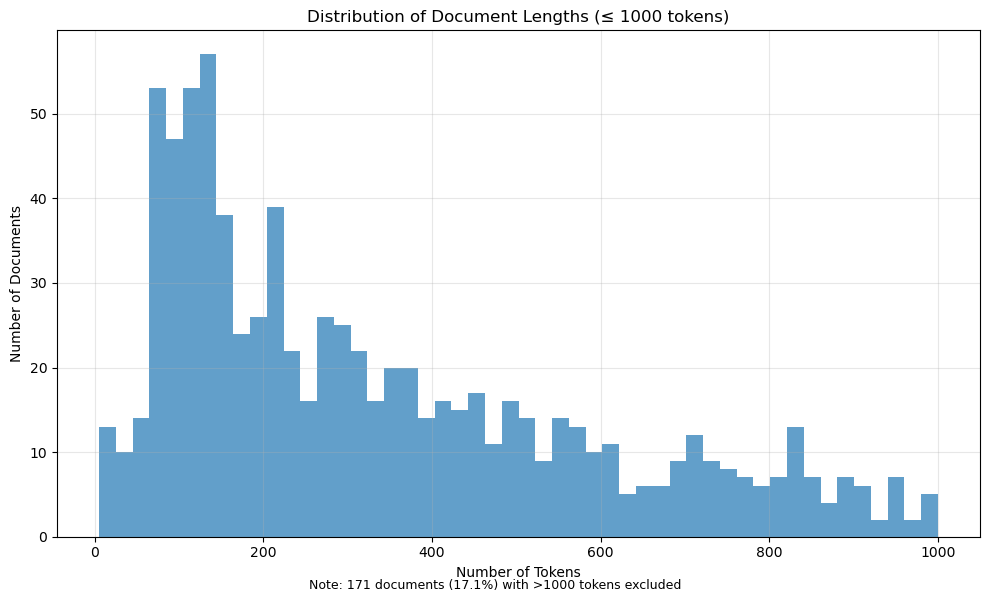

In [52]:
# Optional: If you want to visualize the distribution as a histogram
try:
    import matplotlib.pyplot as plt
    
    # Filter out documents longer than 1000 tokens for better visualization
    filtered_lengths = [length for length in token_lengths if length <= 1000]
    
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_lengths, bins=50, alpha=0.7)
    plt.title('Distribution of Document Lengths (≤ 1000 tokens)')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Number of Documents')
    plt.grid(True, alpha=0.3)
    
    # Add a note about excluded documents
    excluded_count = len(token_lengths) - len(filtered_lengths)
    excluded_percent = (excluded_count / len(token_lengths)) * 100 if token_lengths else 0
    plt.figtext(0.5, 0.01, 
                f'Note: {excluded_count} documents ({excluded_percent:.1f}%) with >1000 tokens excluded', 
                ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('document_length_distribution.png')
    print(f"\nHistogram saved as 'document_length_distribution.png'")
    print(f"Note: {excluded_count} documents ({excluded_percent:.1f}%) with >1000 tokens were excluded from the visualization")
except ImportError:
    print("\nMatplotlib not available for visualization. Install with 'pip install matplotlib'")
except Exception as e:
    print(f"\nCould not generate visualization: {e}")